In [2]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, WhiteKernel, RBF
import matplotlib.pyplot as plt
from matplotlib import rc
import matplotlib as mpl
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams["font.size"] = 14
mpl.rcParams["ytick.labelsize"] = 12
mpl.rcParams["xtick.labelsize"] = 12

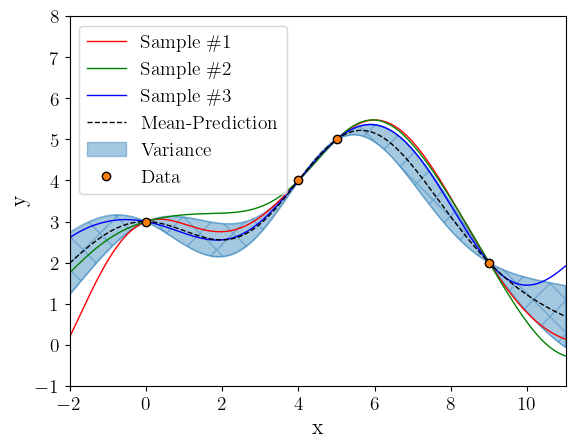

In [4]:
#rc('font',**{'family':'serif','serif':['Palatino']})
#rc('text', usetex=True)
fig, ax = plt.subplots()
ax.set_xlabel("x", fontdict={"fontname":"Palatino Linotype", "fontsize":16})
ax.set_ylabel("y", fontdict={"fontname":"Palatino Linotype", "fontsize":16})


ax.set_xlim([-2.0, 11.0])
ax.set_ylim([-1.0,8.0])
ax.tick_params(axis='both', labelsize=14)
xs = np.linspace(-2.0, 11.0, 200)


x_data = np.array([0.0, 4.0, 5.0, 9.0])
y_data = np.array([3.0,4.0, 5.0, 2.0])

gpr = GaussianProcessRegressor(kernel=RBF(), random_state=0).fit(x_data.reshape(-1,1), y_data)
ys, std_vars = gpr.predict(X=xs.reshape(-1,1), return_std=True)
for i, color in enumerate(["red", "green", "blue"]):
        y_s = gpr.sample_y(X=xs.reshape(-1,1), random_state=i)
        ax.plot(xs,y_s, label=rf"Sample $\#${i+1}", lw=1, color=color)

ax.plot(xs,ys, ls="--", c="k", lw=1, label="Mean-Prediction")

ax.fill_between(x=xs, y1=ys-std_vars, y2=ys+std_vars, alpha=0.4, color="C0", label="Variance")
ax.fill_between(x=xs, y1=ys-std_vars, y2=ys+std_vars, alpha=0.4, hatch="x", color="None", edgecolor="C0")
ax.plot(x_data, y_data, 'o', color="C1", markeredgecolor="k", label="Data")
ax.legend()
plt.savefig("gpr_reg.pdf")

In [ ]:
print(std_vars)